# Experiment 1: Model Comparison for Status Decrease Prediction

This notebook runs and visualises the results of **Experiment 1**, which trains three models 
(Logistic Regression, XGBoost, CatBoost) on the same data split and compares their performance 
on predicting *Status Decrease*.

**Predictor selection** supports two modes:
- **Inclusion-based**: pass `predictory_columns` directly to select specific features.
- **Exclusion-based**: pass `exclude_columns` and all remaining valid columns are used.

**Target horizon** is configurable: set `target_horizon=0` to predict the target from 
the same row as covariates, or `target_horizon=1` to predict the next row.

**This notebook does not reimplement any experiment logic.** It imports and calls 
`run_experiment()` from `scripts/Experiment1.py`, then focuses on visualisation.

Each experiment cell below tests a different combination of predictors, lag, and 
target variable. Additional cells can be added to explore further configurations.

## 1. Setup

In [2]:
import sys
from pathlib import Path

# Add project root to path so we can import scripts/ and src/
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

from scripts.Experiment1 import run_experiment

# Plot styling
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f'Project root: {project_root}')
print('Setup complete. Use run_experiment() in the cells below.')

ModuleNotFoundError: No module named 'xgboost'

## 2. Run the Experiment

`run_experiment()` supports two predictor selection modes:

- **Exclusion-based** (`exclude_columns`): exclude specific columns; all others become predictors.
- **Inclusion-based** (`predictory_columns`): specify exact predictor columns. Takes precedence
  if both are provided.

Each cell below tests a different configuration. Add more cells to explore other
combinations of predictors, lag values, and target variables.

In [ ]:
# === EXPERIMENT CONFIGURATION ===
# Exclusion-based: exclude free-text comments and post-assessment variables.
# All remaining valid columns become predictors automatically.
experiment_results = run_experiment(
    target='Status Decrease',
    lag=3,
    exclude_columns=['Comment Yesterday', 'Activity Type Today'],
    target_horizon=1,
    hpo_trials=20,
    verbose=True,
)

## 3. ROC Curves

Plot the ROC curve for each model on the test set. The optimal threshold (from Youden's J 
statistic) is marked with a star.

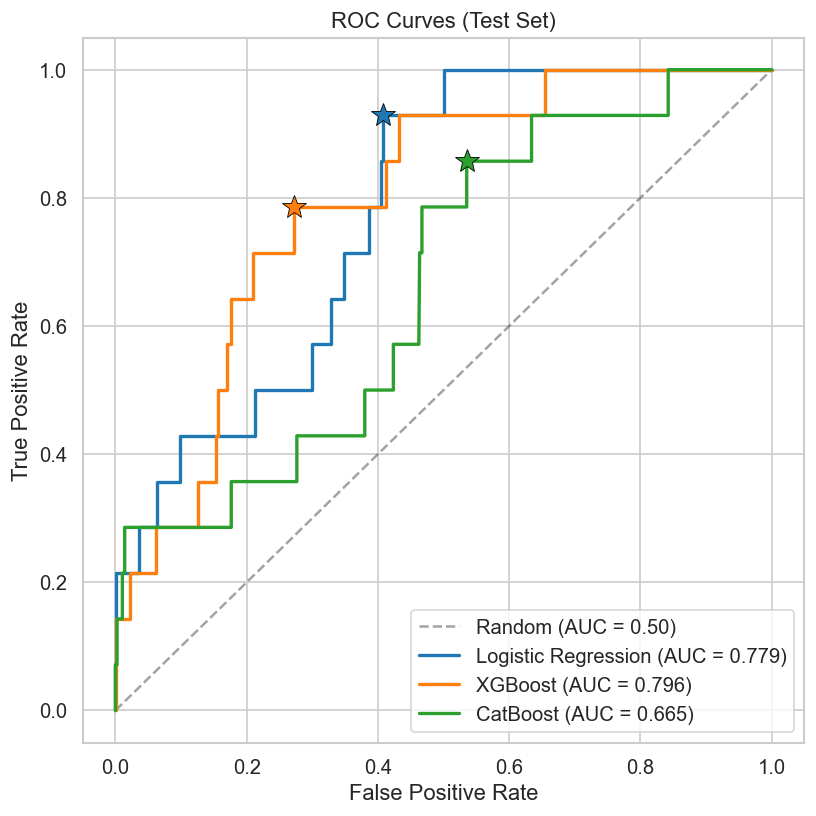

In [ ]:
colors = {'Logistic Regression': '#1f77b4', 'XGBoost': '#ff7f0e', 'CatBoost': '#2ca02c'}

fig, ax = plt.subplots(figsize=(7, 7))

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.50)')

for model_name, results in experiment_results['models'].items():
    if results is None or results['task_type'] != 'classification':
        continue

    y_true = results['y_test_true']
    y_prob = results['y_test_pred']
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    auc_val = results['metrics']['roc_auc']
    opt_thresh = results['metrics']['optimal_threshold']

    ax.plot(fpr, tpr, color=colors.get(model_name, 'grey'),
            label=f'{model_name} (AUC = {auc_val:.3f})', linewidth=2)

    # Mark the optimal threshold point (Youden's J)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    ax.plot(fpr[opt_idx], tpr[opt_idx], '*', color=colors.get(model_name, 'grey'),
            markersize=15, markeredgecolor='black', markeredgewidth=0.5)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Test Set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 4. Precision-Recall Curves

For imbalanced problems like Status Decrease, the PR curve is often more informative than the 
ROC curve because it focuses on the rare positive class.

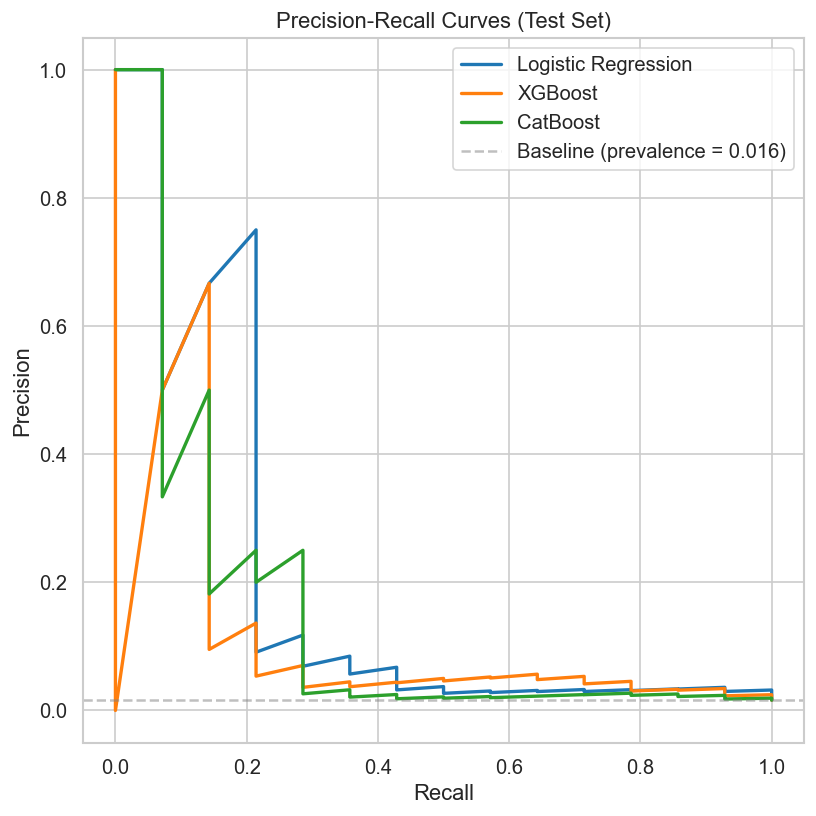

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

for model_name, results in experiment_results['models'].items():
    if results is None or results['task_type'] != 'classification':
        continue

    y_true = results['y_test_true']
    y_prob = results['y_test_pred']
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)

    ax.plot(recall_vals, precision_vals, color=colors.get(model_name, 'grey'),
            label=model_name, linewidth=2)

# Baseline: prevalence of the positive class
first_result = next(r for r in experiment_results['models'].values() if r is not None)
prevalence = first_result['y_test_true'].mean()
ax.axhline(y=prevalence, color='grey', linestyle='--', alpha=0.5,
           label=f'Baseline (prevalence = {prevalence:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (Test Set)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

One confusion matrix per model, using the Youden's J optimal threshold.

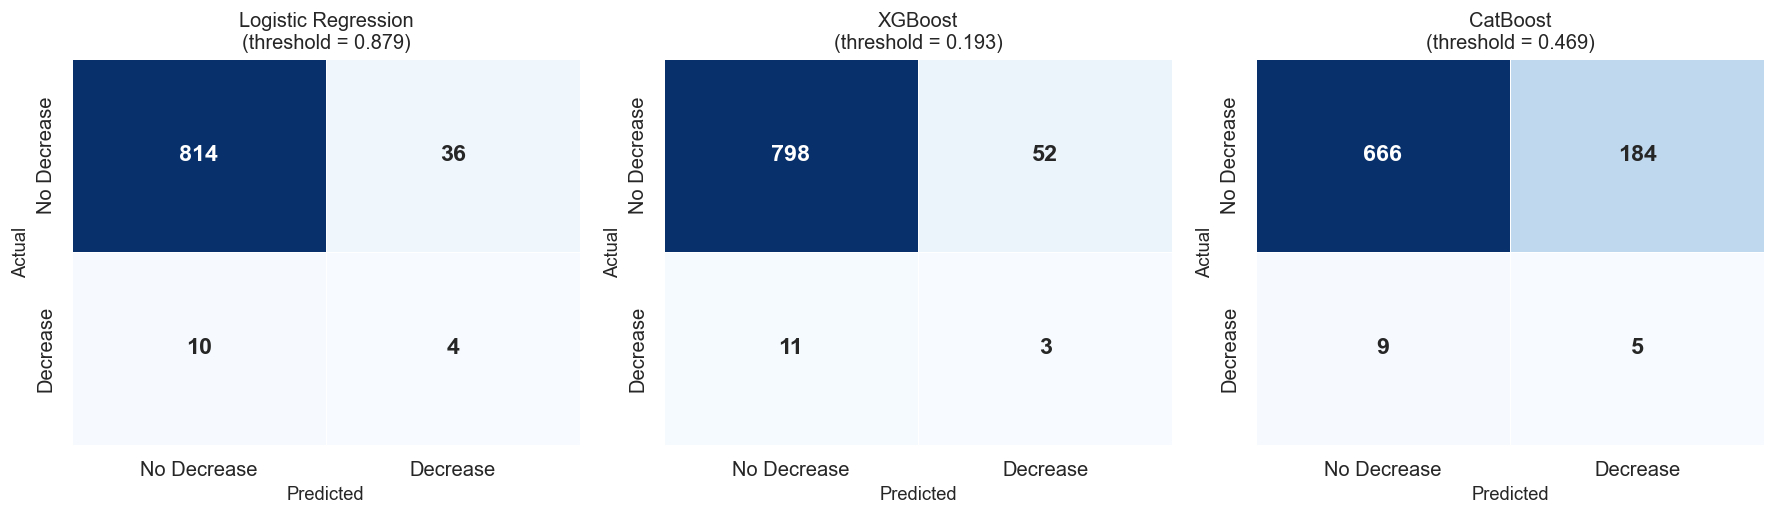

In [ ]:
successful_models = {k: v for k, v in experiment_results['models'].items() if v is not None}
n_models = len(successful_models)

fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

labels = ['No Decrease', 'Decrease']

for ax, (model_name, results) in zip(axes, successful_models.items()):
    if results['task_type'] != 'classification':
        continue

    y_true = results['y_test_true']
    y_prob = results['y_test_pred']
    opt_thresh = results['metrics']['optimal_threshold']
    y_pred = (y_prob >= opt_thresh).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    # Use sns.heatmap for clean visualisation (no ugly cross marks)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'fontweight': 'bold'}, ax=ax)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{model_name}\n(threshold = {opt_thresh:.3f})', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Feature Importance (Per Model)

Compare the top features across models. Logistic Regression provides coefficient magnitudes; 
tree models provide gain-based importance.

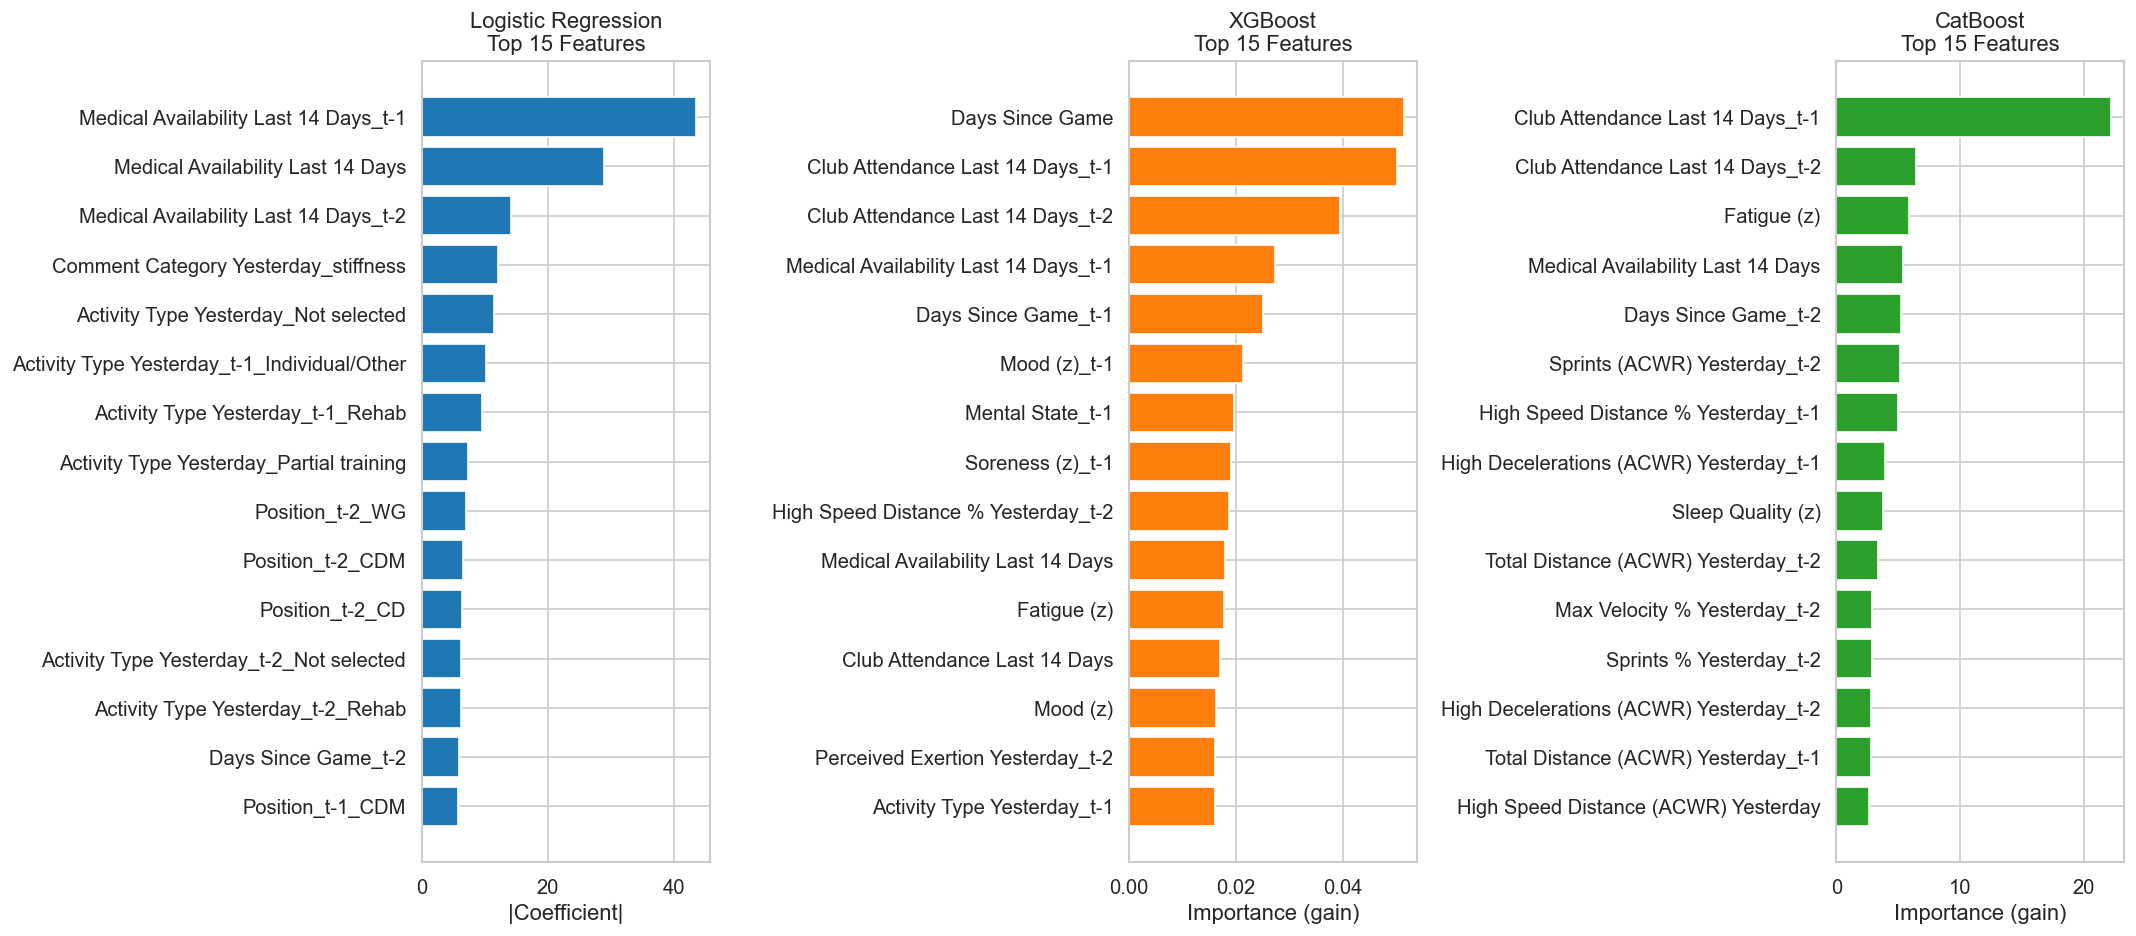

In [ ]:
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 8))
if n_models == 1:
    axes = [axes]

top_n = 15  # Show top N features

for ax, (model_name, results) in zip(axes, successful_models.items()):
    weights = results['model_weights']
    feature_names = weights['feature_names']

    if 'coefficients' in weights and weights['coefficients'] is not None:
        # Logistic Regression: use absolute coefficient values
        coefs = np.abs(np.array(weights['coefficients']).flatten())
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': coefs
        })
        importance_label = '|Coefficient|'
    elif 'feature_importances' in weights:
        # Tree models: use gain-based importance
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': weights['feature_importances']
        })
        importance_label = 'Importance (gain)'
    else:
        continue

    importance_df = importance_df.sort_values('importance', ascending=True).tail(top_n)

    ax.barh(importance_df['feature'], importance_df['importance'],
            color=colors.get(model_name, 'steelblue'))
    ax.set_xlabel(importance_label)
    ax.set_title(f'{model_name}\nTop {top_n} Features')

plt.tight_layout()
plt.show()

## 7. Averaged Feature Importance Across All Models

Each model uses a different importance metric (|coefficients| for LogReg, gain for tree models).
To compare fairly, we normalise each model's importances to the [0, 1] range (min-max scaling)
and then average across all successful models. This reveals which features are **consistently**
important regardless of the modelling approach.

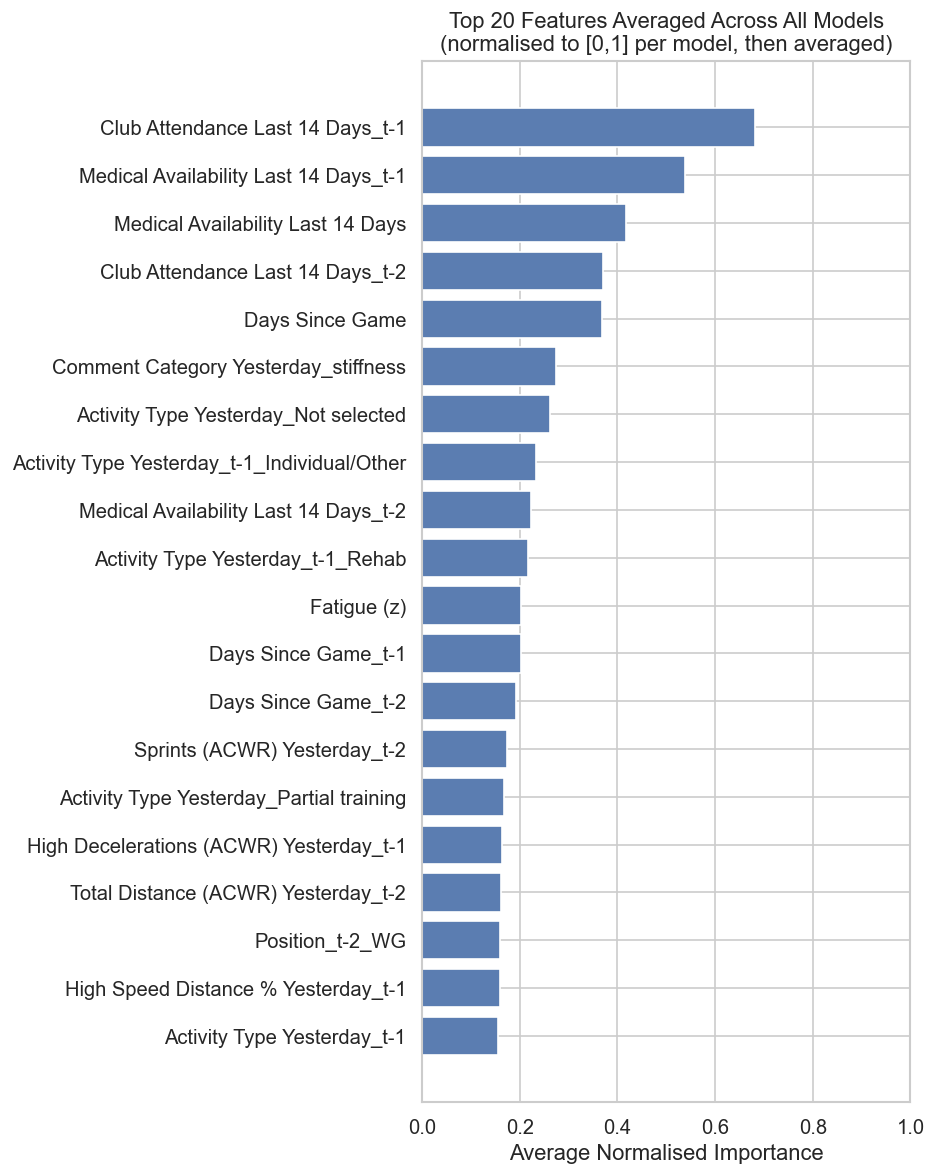


Averaged importance computed across 3 models: ['Logistic Regression', 'XGBoost', 'CatBoost']


In [ ]:
# Collect normalised importances from each model
all_importances = {}

for model_name, results in successful_models.items():
    if results is None:
        continue

    weights = results['model_weights']
    feature_names = weights['feature_names']

    if 'coefficients' in weights and weights['coefficients'] is not None:
        raw = np.abs(np.array(weights['coefficients']).flatten())
    elif 'feature_importances' in weights:
        raw = np.array(weights['feature_importances'])
    else:
        continue

    # Min-max normalise to [0, 1] so models are comparable
    raw_min, raw_max = raw.min(), raw.max()
    if raw_max - raw_min > 0:
        normalised = (raw - raw_min) / (raw_max - raw_min)
    else:
        normalised = np.zeros_like(raw)

    for fname, val in zip(feature_names, normalised):
        if fname not in all_importances:
            all_importances[fname] = []
        all_importances[fname].append(val)

# Average across models (only features present in all models contribute fairly)
avg_importance = {
    fname: np.mean(vals)
    for fname, vals in all_importances.items()
}

avg_df = pd.DataFrame([
    {'feature': k, 'avg_normalised_importance': v}
    for k, v in avg_importance.items()
]).sort_values('avg_normalised_importance', ascending=True)

# Plot top N averaged features
top_n_avg = 20
plot_df = avg_df.tail(top_n_avg)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(plot_df['feature'], plot_df['avg_normalised_importance'], color='#5B7DB1')
ax.set_xlabel('Average Normalised Importance')
ax.set_title(f'Top {top_n_avg} Features Averaged Across All Models\n'
             f'(normalised to [0,1] per model, then averaged)')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

print(f'\nAveraged importance computed across {len(successful_models)} models: '
      f'{list(successful_models.keys())}')

## 8. Threshold Sensitivity Analysis

Show how F1, Precision, and Recall change across different probability thresholds for each 
model. The vertical line marks the Youden's J optimal threshold.

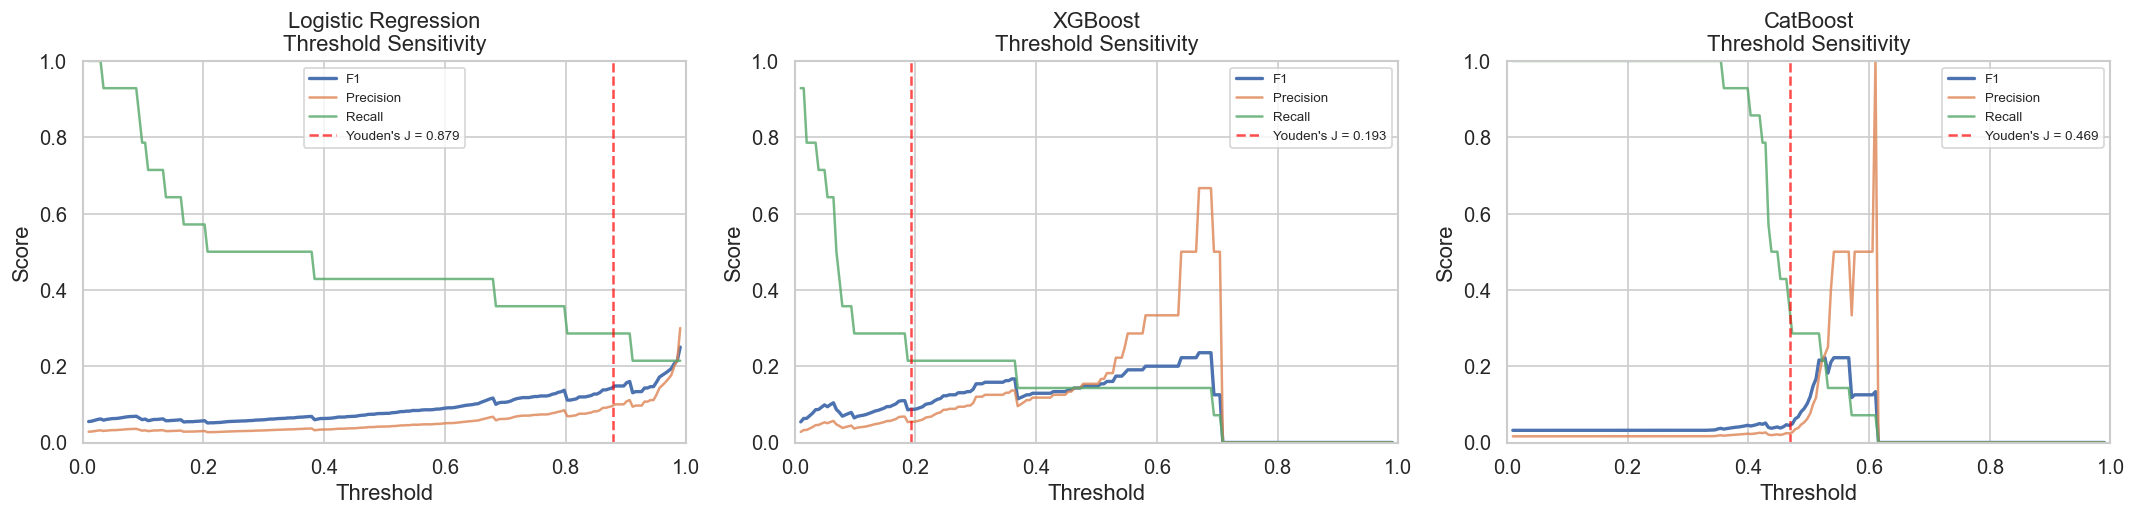

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (model_name, results) in zip(axes, successful_models.items()):
    if results['task_type'] != 'classification':
        continue

    y_true = results['y_test_true']
    y_prob = results['y_test_pred']
    opt_thresh = results['metrics']['optimal_threshold']

    thresholds_range = np.linspace(0.01, 0.99, 200)
    f1_scores, prec_scores, rec_scores = [], [], []

    for t in thresholds_range:
        y_pred_t = (y_prob >= t).astype(int)
        f1_scores.append(f1_score(y_true, y_pred_t, zero_division=0))
        prec_scores.append(precision_score(y_true, y_pred_t, zero_division=0))
        rec_scores.append(recall_score(y_true, y_pred_t, zero_division=0))

    ax.plot(thresholds_range, f1_scores, label='F1', linewidth=2)
    ax.plot(thresholds_range, prec_scores, label='Precision', linewidth=1.5, alpha=0.8)
    ax.plot(thresholds_range, rec_scores, label='Recall', linewidth=1.5, alpha=0.8)
    ax.axvline(x=opt_thresh, color='red', linestyle='--', alpha=0.7,
               label=f"Youden's J = {opt_thresh:.3f}")
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name}\nThreshold Sensitivity')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Summary

Print the final experiment configuration and results overview.

In [ ]:
print('=== Experiment Configuration ===')
config = experiment_results['config']
print(f'  Target:           {config["target"]}')
print(f'  Target Horizon:   t+{config["target_horizon"]}')
print(f'  Selection Mode:   {config["selection_mode"]}')
print(f'  Lag:              {config["lag"]}')
print(f'  Test Size:        {config["test_size"]}')
print(f'  Val Size:         {config["val_size"]}')
print(f'  HPO Trials:       {config["hpo_trials"]}')
if config.get('exclude_columns'):
    print(f'  Excluded Columns: {config["exclude_columns"]}')
print(f'  Predictors ({len(config["predictors"])}):')
for p in config['predictors']:
    print(f'    - {p}')

print(f'\n=== Results Summary ===')
summary = experiment_results['summary']
print(f'  Total models:  {summary["total"]}')
print(f'  Successful:    {summary["successful"]}')
print(f'  Failed:        {summary["failed"]}')
if summary['failed_models']:
    print(f'  Failed models: {summary["failed_models"]}')

print(f'\n=== Performance Comparison ===')
comparison_df = pd.DataFrame(experiment_results['comparison']).set_index('model')
display_cols = ['roc_auc', 'f1', 'precision', 'recall', 'accuracy', 'optimal_threshold']
display(comparison_df[display_cols])